In [ ]:
# Exercicio 2

import asyncio
import random
import time

async def baixar_arquivo(nome_arquivo):
    if nome_arquivo == "virus.exe":
        raise Exception("Arquivo malicioso detectado!")

    print(f"Iniciando download: {nome_arquivo}")
    tempo = random.randint(1, 5)
    await asyncio.sleep(tempo)
    print(f"Finalizado: {nome_arquivo} ({tempo}s)")
    return nome_arquivo

async def main():
    arquivos = ["file1.txt", "file2.txt", "virus.exe", "file3.txt", "file4.txt"]

    inicio = time.time()

    tarefas = [baixar_arquivo(a) for a in arquivos]

    resultados = await asyncio.gather(*tarefas, return_exceptions=True)

    fim = time.time()

    print("\nRelatório final:")
    for r in resultados:
        if isinstance(r, Exception):
            print("Erro:", r)
        else:
            print("Baixado:", r)

    print(f"\nTempo total: {fim - inicio:.2f} segundos")


try:
    loop = asyncio.get_running_loop()
    # Se já existir loop (VS Code / Jupyter)
    await main()
except RuntimeError:
    # Se NÃO existir loop (arquivo .py normal)
    asyncio.run(main())

Iniciando download: file1.txt
Iniciando download: file2.txt
Iniciando download: file3.txt
Iniciando download: file4.txt
Finalizado: file3.txt (2s)
Finalizado: file1.txt (3s)
Finalizado: file4.txt (3s)
Finalizado: file2.txt (4s)

Relatório final:
Baixado: file1.txt
Baixado: file2.txt
Erro: Arquivo malicioso detectado!
Baixado: file3.txt
Baixado: file4.txt

Tempo total: 4.00 segundos


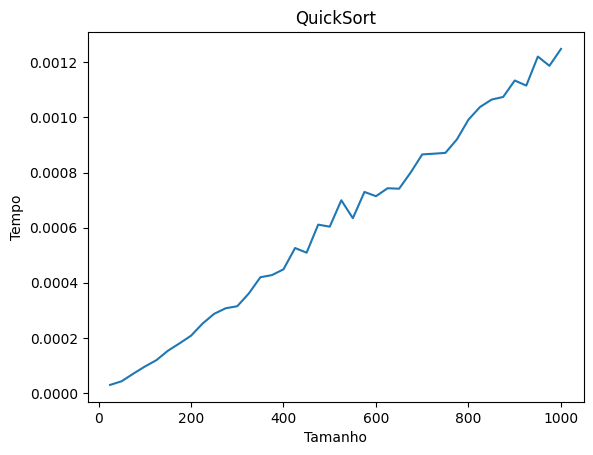

In [ ]:
# Exercicio 3

import random
import time
import matplotlib.pyplot as plt

def quicksort(arr):
    if len(arr) <= 1:
        return arr
    pivo = arr[len(arr)//2]
    menores = [x for x in arr if x < pivo]
    iguais = [x for x in arr if x == pivo]
    maiores = [x for x in arr if x > pivo]
    return quicksort(menores) + iguais + quicksort(maiores)

# Testes
tamanhos = list(range(25, 1001, 25))
tempos = []

for n in tamanhos:
    lista = [random.randint(0, 10000) for _ in range(n)]
    inicio = time.time()
    quicksort(lista)
    tempos.append(time.time() - inicio)

plt.plot(tamanhos, tempos)
plt.xlabel("Tamanho")
plt.ylabel("Tempo")
plt.title("QuickSort")
plt.show()

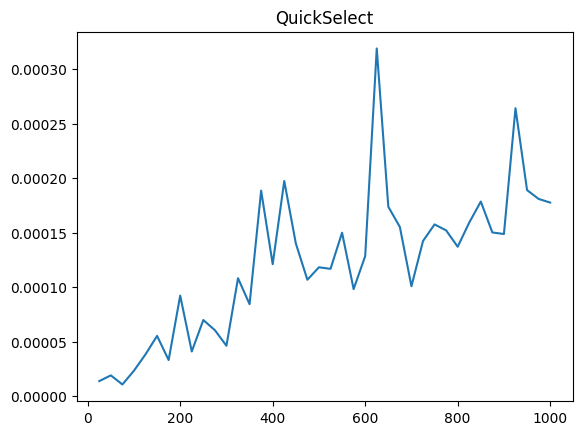

In [ ]:
# Exercicio 4

import random
import time
import matplotlib.pyplot as plt

def quickselect(arr, k):
    if len(arr) == 1:
        return arr[0]
    
    pivo = random.choice(arr)
    menores = [x for x in arr if x < pivo]
    iguais = [x for x in arr if x == pivo]
    maiores = [x for x in arr if x > pivo]

    if k < len(menores):
        return quickselect(menores, k)
    elif k < len(menores) + len(iguais):
        return pivo
    else:
        return quickselect(maiores, k - len(menores) - len(iguais))

# Teste
tamanhos = list(range(25, 1001, 25))
tempos = []

for n in tamanhos:
    lista = [random.randint(0, 10000) for _ in range(n)]
    k = random.randint(0, n-1)
    inicio = time.time()
    quickselect(lista, k)
    tempos.append(time.time() - inicio)

plt.plot(tamanhos, tempos)
plt.title("QuickSelect")
plt.show()

In [ ]:
# Exercicio 5

class No:
    def __init__(self, texto):
        self.texto = texto
        self.prev = None
        self.next = None

class ListaDupla:
    def __init__(self):
        self.inicio = None

    def inserir(self, texto):
        novo = No(texto)
        if not self.inicio:
            self.inicio = novo
            return
        
        atual = self.inicio
        while atual.next:
            atual = atual.next
        
        atual.next = novo
        novo.prev = atual

    def listar(self):
        atual = self.inicio
        while atual:
            print(atual.texto)
            atual = atual.next

# Teste
l = ListaDupla()
l.inserir("A natureza,")
l.inserir("dizem-nos,")
l.inserir("é apenas o hábito...")
l.listar()

A natureza,
dizem-nos,
é apenas o hábito...


In [ ]:
# Exercicio 6

linhas = []

while True:
    cmd = input(">> ")

    if cmd.startswith("I"):
        texto = input("Digite texto: ")
        linhas.append(texto)

    elif cmd.startswith("L"):
        for i, l in enumerate(linhas):
            print(i, l)

    elif cmd.startswith("E"):
        i = int(input("Linha: "))
        if 0 <= i < len(linhas):
            linhas.pop(i)

    elif cmd.startswith("F"):
        break

In [ ]:
# Exercicio 7

def soma(d):
    total = 0
    for k, v in d.items():
        if isinstance(v, dict):
            total += soma(v)
        else:
            total += v
    return total

In [ ]:
# Exercicio 8

def regua(n):
    if n == 0:
        return
    regua(n-1)
    print("-" * n)
    regua(n-1)

regua(4)

-
--
-
---
-
--
-
----
-
--
-
---
-
--
-


In [15]:
# Exercicio 10

import asyncio
import random

async def produtor(fila):
    try:
        while True:
            valor = random.randint(40, 180)
            await fila.put(valor)
            await asyncio.sleep(0.5)
    except asyncio.CancelledError:
        print("Produtor encerrado.")

async def consumidor(fila):
    try:
        while True:
            v = await fila.get()
            if v > 120:
                print("ALERTA:", v)
            else:
                print("Normal:", v)
    except asyncio.CancelledError:
        print("Consumidor encerrado.")

async def main():
    fila = asyncio.Queue(10)

    p = asyncio.create_task(produtor(fila))
    c = asyncio.create_task(consumidor(fila))

    await asyncio.sleep(10)

    p.cancel()
    c.cancel()

    await asyncio.gather(p, c, return_exceptions=True)


try:
    loop = asyncio.get_running_loop()
    await main()
except RuntimeError:
    asyncio.run(main())

Normal: 51
Normal: 72
ALERTA: 154
ALERTA: 161
Normal: 87
Normal: 41
ALERTA: 139
Normal: 107
Normal: 72
ALERTA: 136
Normal: 111
ALERTA: 167
Normal: 110
ALERTA: 128
Normal: 49
Normal: 67
ALERTA: 180
Normal: 114
Normal: 110
Normal: 110
Produtor encerrado.
Consumidor encerrado.


In [ ]:
# Exercicio 11

import random

n = 20
a = [[random.randint(1,20) for _ in range(n)] for _ in range(2)]
t = [[random.randint(1,10) for _ in range(n)] for _ in range(2)]
e = [random.randint(1,10) for _ in range(2)]
x = [random.randint(1,10) for _ in range(2)]

def linha(i, j):
    if j == 0:
        return e[i] + a[i][j]
    
    return min(
        linha(i, j-1) + a[i][j],
        linha(1-i, j-1) + t[1-i][j] + a[i][j]
    )

res = min(linha(0,n-1)+x[0], linha(1,n-1)+x[1])
print(res)

172


In [ ]:
# Exercicio 12

def linha3(i, j):
    if j == 0:
        return e[i] + a[i][j]

    return min([
        linha3(k, j-1) + (0 if k==i else t[k][j]) + a[i][j]
        for k in range(3)
    ])